In [1]:
123

123

In [52]:
# 1. 라이브러리
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

In [3]:
# 2. 경로 설정
# 프로젝트 최상위 폴더 탐색
current_path = Path.cwd().resolve()

PROJECT_ROOT = next(
    (
        path
        for path in [current_path, *current_path.parents]
        if (path / "data" / "interim").exists()
    ),
    None
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "data/interim 폴더를 찾을 수 없습니다."
    )

INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
REPORT_TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
REPORT_FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

REPORT_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

REPORT_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESTAURANT_REVIEW_PATH = (
    INTERIM_DIR
    / "restaurant_reviews.parquet"
)

print(
    "음식점 리뷰 파일 존재:",
    RESTAURANT_REVIEW_PATH.exists()
)

음식점 리뷰 파일 존재: True


In [53]:
# 분석 설정 파일 경로
CONFIG_PATH = (
    PROJECT_ROOT
    / "configs"
    / "analysis_config.yaml"
)

print("설정 파일 존재:", CONFIG_PATH.exists())
print("설정 파일 경로:", CONFIG_PATH)

설정 파일 존재: True
설정 파일 경로: C:\Users\playdata2\SKN34-2nd-5Team\configs\analysis_config.yaml


In [54]:
with CONFIG_PATH.open(
    mode="r",
    encoding="utf-8"
) as file:
    config = yaml.safe_load(file)

config

{'project': {'name': 'yelp-reviewer-churn',
  'cohort_version': 'v01',
  'random_state': 42},
 'business_scope': {'required_category': 'Restaurants'},
 'power_reviewer': {'baseline_start': '2017-01-01',
  'baseline_end': '2018-01-01',
  'minimum_review_count': 10,
  'minimum_active_months': 3},
 'recent_activity': {'observation_start': '2018-01-01',
  'observation_end': '2019-01-01',
  'continuity_start': '2018-07-01',
  'minimum_continuity_reviews': 1},
 'target': {'prediction_start': '2019-01-01',
  'prediction_end': '2020-01-01',
  'churn_max_review_count': 0}}

In [55]:
power_config = config[
    "power_reviewer"
]

recent_config = config[
    "recent_activity"
]

target_config = config[
    "target"
]

print("파워 리뷰어 설정:", power_config)
print("최근 활동 설정:", recent_config)
print("타깃 설정:", target_config)

파워 리뷰어 설정: {'baseline_start': '2017-01-01', 'baseline_end': '2018-01-01', 'minimum_review_count': 10, 'minimum_active_months': 3}
최근 활동 설정: {'observation_start': '2018-01-01', 'observation_end': '2019-01-01', 'continuity_start': '2018-07-01', 'minimum_continuity_reviews': 1}
타깃 설정: {'prediction_start': '2019-01-01', 'prediction_end': '2020-01-01', 'churn_max_review_count': 0}


In [56]:
power_config = config[
    "power_reviewer"
]

recent_config = config[
    "recent_activity"
]

target_config = config[
    "target"
]

print("파워 리뷰어 설정:", power_config)
print("최근 활동 설정:", recent_config)
print("타깃 설정:", target_config)

파워 리뷰어 설정: {'baseline_start': '2017-01-01', 'baseline_end': '2018-01-01', 'minimum_review_count': 10, 'minimum_active_months': 3}
최근 활동 설정: {'observation_start': '2018-01-01', 'observation_end': '2019-01-01', 'continuity_start': '2018-07-01', 'minimum_continuity_reviews': 1}
타깃 설정: {'prediction_start': '2019-01-01', 'prediction_end': '2020-01-01', 'churn_max_review_count': 0}


In [4]:
# 2. 시간 분석용 컬럼만 불러오기
review_time_df = pd.read_parquet(
    RESTAURANT_REVIEW_PATH,
    columns=[
        "user_id",
        "date"
    ],
    dtype_backend="pyarrow"
)

print(
    "시간 분석 데이터 크기:",
    review_time_df.shape
)

review_time_df.head()

시간 분석 데이터 크기: (4724471, 2)


,user_id,date
0,mh_-eMZ6K5RLWhZyISBhwA,2018-07-07 22:09:11
1,8g_iMtfSiwikVnbP2etR0A,2014-02-05 20:30:30
2,_7bHUi9Uuf5__HHc_Q8guQ,2015-01-04 00:01:03
3,bcjbaE6dDog4jkNY91ncLQ,2017-01-14 20:54:15
4,eUta8W_HdHMXPzLBBZhL1A,2015-09-23 23:10:31


In [5]:
# 3. 날짜 자료형 변환
review_time_df["date"] = pd.to_datetime(
    review_time_df["date"],
    errors="coerce"
)

In [6]:
date_validation_df = pd.DataFrame(
    [
        {
            "total_rows": len(review_time_df),
            "date_null_rows": (
                review_time_df["date"]
                .isna()
                .sum()
            ),
            "min_review_date": (
                review_time_df["date"].min()
            ),
            "max_review_date": (
                review_time_df["date"].max()
            )
        }
    ]
)

date_validation_df

,total_rows,date_null_rows,min_review_date,max_review_date
0,4724471,0,2005-02-16 03:23:22,2022-01-19 19:48:25


In [7]:
# 4. 연도별 리뷰 수
review_time_df["year"] = (
    review_time_df["date"].dt.year
)

In [8]:
yearly_review_count_df = (
    review_time_df
    .groupby(
        "year",
        as_index=False
    )
    .size()
    .rename(
        columns={
            "size": "review_count"
        }
    )
)

yearly_review_count_df

,year,review_count
0,2005,620
1,2006,2830
2,2007,10779
3,2008,32419
4,2009,54093
5,2010,100186
6,2011,163639
7,2012,199230
8,2013,261253
9,2014,356834


In [9]:
yearly_review_count_df[
    "review_rate_pct"
] = (
    yearly_review_count_df["review_count"]
    / yearly_review_count_df[
        "review_count"
    ].sum()
    * 100
).round(2)

yearly_review_count_df

,year,review_count,review_rate_pct
0,2005,620,0.01
1,2006,2830,0.06
2,2007,10779,0.23
3,2008,32419,0.69
4,2009,54093,1.14
5,2010,100186,2.12
6,2011,163639,3.46
7,2012,199230,4.22
8,2013,261253,5.53
9,2014,356834,7.55


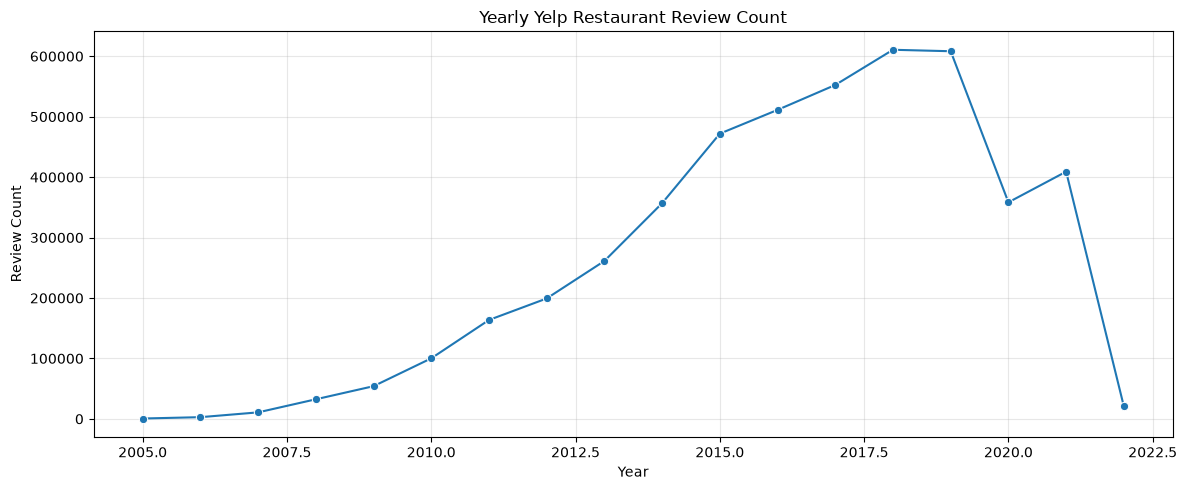

In [10]:
# 5. 연도별 리뷰 추세 시각화
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=yearly_review_count_df,
    x="year",
    y="review_count",
    marker="o"
)

plt.title(
    "Yearly Yelp Restaurant Review Count"
)
plt.xlabel("Year")
plt.ylabel("Review Count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# 6. 월별 리뷰 수
# 월 단위 집계를 위한 연월 생성
review_time_df["review_month"] = (
    review_time_df["date"]
    .dt.to_period("M")
)

In [12]:
monthly_review_count_df = (
    review_time_df
    .groupby(
        "review_month",
        as_index=False
    )
    .size()
    .rename(
        columns={
            "size": "review_count"
        }
    )
)

# 그래프 표시를 위해 Timestamp로 변환
monthly_review_count_df[
    "review_month_date"
] = (
    monthly_review_count_df[
        "review_month"
    ]
    .dt.to_timestamp()
)

monthly_review_count_df.tail(24)

,review_month,review_count,review_month_date
180,2020-02,45864,2020-02-01
181,2020-03,29774,2020-03-01
182,2020-04,13531,2020-04-01
183,2020-05,19733,2020-05-01
184,2020-06,25301,2020-06-01
185,2020-07,29284,2020-07-01
186,2020-08,32080,2020-08-01
187,2020-09,31098,2020-09-01
188,2020-10,31763,2020-10-01
189,2020-11,27534,2020-11-01


In [14]:
# 7. 최근 기간 월별 추세 확인
# 전체 기간보다 2017년 이후를 자세히 보는 게 중요
recent_monthly_df = (
    monthly_review_count_df[
        monthly_review_count_df[
            "review_month_date"
        ] >= "2017-01-01"
    ]
    .copy()
)

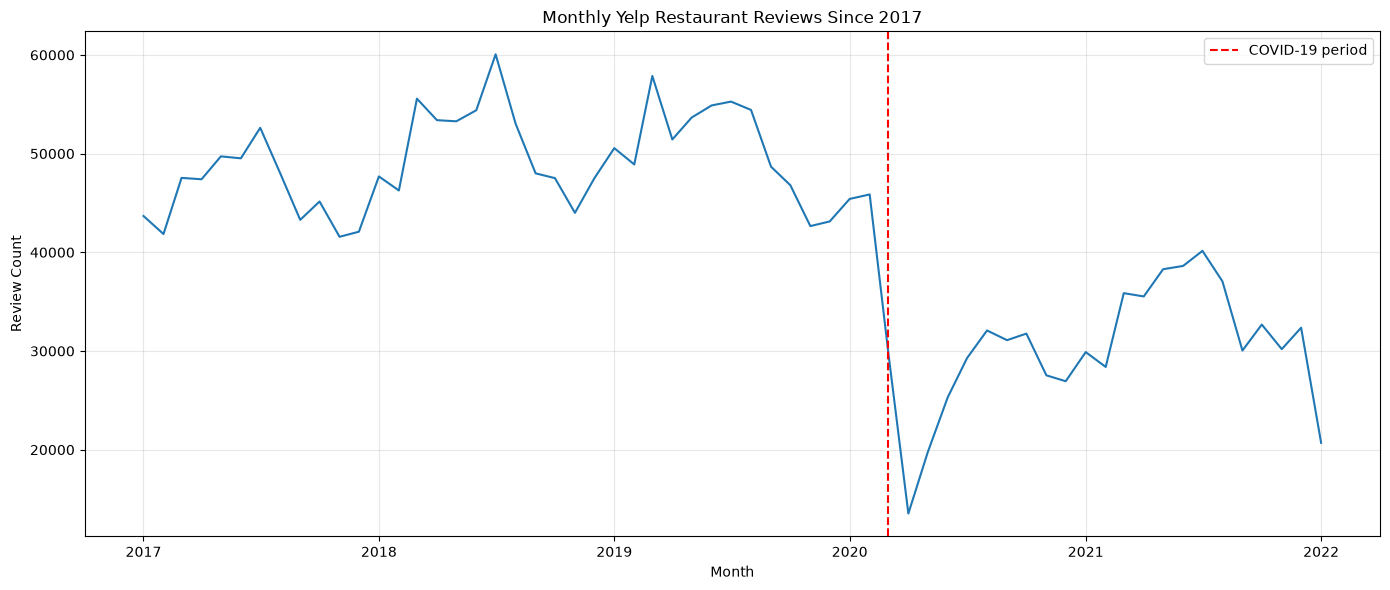

In [15]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=recent_monthly_df,
    x="review_month_date",
    y="review_count"
)

plt.axvline(
    pd.Timestamp("2020-03-01"),
    color="red",
    linestyle="--",
    label="COVID-19 period"
)

plt.title(
    "Monthly Yelp Restaurant Reviews Since 2017"
)
plt.xlabel("Month")
plt.ylabel("Review Count")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<!-- 2020년 전후에 리뷰 수가 크게 달라진다면 코로나19가 탐방 반경과 활동량 감소에 영향을 줄 수 있어. 이 경우 단순한 리뷰어 이탈과 외부 환경 영향을 구분해 해석해야 함. -->

In [16]:
# 8. 사용자별 전체 활동 요약
# 아직 파워 리뷰어를 확정하는 단계는 아님. 사용자별 전체 분포를 확인하기 위한 임시 요약표 생성.
user_activity_summary_df = (
    review_time_df
    .groupby(
        "user_id",
        as_index=False
    )
    .agg(
        restaurant_review_count=(
            "date",
            "count"
        ),
        first_review_date=(
            "date",
            "min"
        ),
        last_review_date=(
            "date",
            "max"
        )
    )
)

In [17]:
user_activity_summary_df[
    "activity_days"
] = (
    user_activity_summary_df[
        "last_review_date"
    ]
    - user_activity_summary_df[
        "first_review_date"
    ]
).dt.days

In [18]:
print(
    "음식점 리뷰 사용자 수:",
    len(user_activity_summary_df)
)

user_activity_summary_df.head()

음식점 리뷰 사용자 수: 1445990


,user_id,restaurant_review_count,first_review_date,last_review_date,activity_days
0,---2PmXbF47D870stH1jqA,22,2012-10-24 13:33:39,2019-04-27 17:35:51,2376
1,---UgP94gokyCDuB5zUssA,10,2014-11-02 15:10:18,2021-09-17 17:36:13,2511
2,---r61b7EpVPkb4UVme5tA,3,2014-05-06 14:00:28,2016-11-13 12:35:37,921
3,---zemaUC8WeJeWKqS6p9Q,1,2021-06-23 08:17:42,2021-06-23 08:17:42,0
4,--0DrQkM0FT-yCQRWw82uQ,1,2012-10-15 05:59:48,2012-10-15 05:59:48,0


In [19]:
# 9. 사용자별 리뷰 수 분포
user_activity_summary_df[
    "restaurant_review_count"
].describe(
    percentiles=[
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

count    1.445990e+06
mean     3.267292e+00
std      1.024263e+01
min      1.000000e+00
50%      1.000000e+00
75%      3.000000e+00
90%      6.000000e+00
95%      1.000000e+01
99%      3.300000e+01
max      1.704000e+03
Name: restaurant_review_count, dtype: float64

In [ ]:
# 10. 파워 리뷰어 임시 후보 기준 비교
# 이 기준은 전체 기간을 사용한 사전 검증용. 최종 모델에서는 관찰 기간 내 리뷰만으로 다시 계산해야 함.
thresholds = [
    10,
    20,
    30,
    50,
    100
]

candidate_results = []

total_user_count = len(
    user_activity_summary_df
)

for threshold in thresholds:
    candidate_count = (
        user_activity_summary_df[
            "restaurant_review_count"
        ] >= threshold
    ).sum()

    candidate_results.append(
        {
            "minimum_review_count": threshold,
            "candidate_user_count": (
                candidate_count
            ),
            "candidate_rate_pct": round(
                candidate_count
                / total_user_count
                * 100,
                2
            )
        }
    )

power_reviewer_candidate_df = pd.DataFrame(
    candidate_results
)

power_reviewer_candidate_df

,minimum_review_count,candidate_user_count,candidate_rate_pct
0,10,77443,5.36
1,20,29643,2.05
2,30,17143,1.19
3,50,8026,0.56
4,100,2457,0.17


In [22]:
# 11. 활동 기간까지 포함한 후보 비교
# 리뷰 수만 많고 짧은 기간에 몰아서 작성한 사용자와 장기간 꾸준히 활동한 사용자를 구분하기 위한 분석.
activity_candidate_results = []

for threshold in [10, 20, 30, 50]:
    for minimum_days in [
        180,
        365,
        730
    ]:
        candidate_count = (
            (
                user_activity_summary_df[
                    "restaurant_review_count"
                ] >= threshold
            )
            & (
                user_activity_summary_df[
                    "activity_days"
                ] >= minimum_days
            )
        ).sum()

        activity_candidate_results.append(
            {
                "minimum_review_count": threshold,
                "minimum_activity_days": (
                    minimum_days
                ),
                "candidate_user_count": (
                    candidate_count
                ),
                "candidate_rate_pct": round(
                    candidate_count
                    / total_user_count
                    * 100,
                    2
                )
            }
        )

power_reviewer_activity_candidate_df = (
    pd.DataFrame(
        activity_candidate_results
    )
)

power_reviewer_activity_candidate_df

,minimum_review_count,minimum_activity_days,candidate_user_count,candidate_rate_pct
0,10,180,73208,5.06
1,10,365,69488,4.81
2,10,730,61041,4.22
3,20,180,29075,2.01
4,20,365,28238,1.95
5,20,730,25886,1.79
6,30,180,16969,1.17
7,30,365,16643,1.15
8,30,730,15526,1.07
9,50,180,7988,0.55


In [23]:
# 12. 결과 저장
yearly_review_count_df.to_csv(
    REPORT_TABLE_DIR
    / "yearly_restaurant_review_counts.csv",
    index=False,
    encoding="utf-8-sig"
)

monthly_review_count_df.to_csv(
    REPORT_TABLE_DIR
    / "monthly_restaurant_review_counts.csv",
    index=False,
    encoding="utf-8-sig"
)

power_reviewer_candidate_df.to_csv(
    REPORT_TABLE_DIR
    / "power_reviewer_count_candidates.csv",
    index=False,
    encoding="utf-8-sig"
)

power_reviewer_activity_candidate_df.to_csv(
    REPORT_TABLE_DIR
    / "power_reviewer_activity_candidates.csv",
    index=False,
    encoding="utf-8-sig"
)

user_activity_summary_df.to_parquet(
    INTERIM_DIR
    / "user_activity_summary_preliminary.parquet",
    index=False
)

print("시간 구조 검증 결과 저장 완료")

시간 구조 검증 결과 저장 완료


In [ ]:
# 1. 기간별 사용자 활동표 생성
# 코로나19 이전의 안정적인 분석 기간만 추출
stable_period_df = (
    review_time_df[
        (review_time_df["date"] >= "2017-01-01")
        & (review_time_df["date"] < "2020-01-01")
    ][
        [
            "user_id",
            "date"
        ]
    ]
    .copy()
)

print(
    "2017~2019년 리뷰 수:",
    len(stable_period_df)
)

2017~2019년 리뷰 수: 1771409


In [25]:
# 분석 기간 구분
def assign_analysis_period(review_date):
    """
    리뷰 날짜를 프로젝트 분석 기간으로 구분한다.
    """
    if review_date < pd.Timestamp("2018-01-01"):
        return "baseline_2017"

    if review_date < pd.Timestamp("2019-01-01"):
        return "change_2018"

    return "target_2019"

In [26]:
stable_period_df["period"] = (
    stable_period_df["date"]
    .apply(assign_analysis_period)
)

stable_period_df["review_month"] = (
    stable_period_df["date"]
    .dt.to_period("M")
)

stable_period_df[
    ["date", "period", "review_month"]
].head()

,date,period,review_month
0,2018-07-07 22:09:11,change_2018,2018-07
3,2017-01-14 20:54:15,baseline_2017,2017-01
17,2018-07-17 03:30:07,change_2018,2018-07
23,2017-02-19 13:32:05,baseline_2017,2017-02
24,2017-01-02 03:17:34,baseline_2017,2017-01


In [27]:
stable_period_df["period"].value_counts()

period
change_2018      610694
target_2019      608268
baseline_2017    552447
Name: count, dtype: int64

In [28]:
# 2. 사용자·기간별 활동 집계
user_period_activity_df = (
    stable_period_df
    .groupby(
        [
            "user_id",
            "period"
        ],
        as_index=False
    )
    .agg(
        review_count=(
            "date",
            "count"
        ),
        active_months=(
            "review_month",
            "nunique"
        ),
        first_review_date=(
            "date",
            "min"
        ),
        last_review_date=(
            "date",
            "max"
        )
    )
)

user_period_activity_df.head()

,user_id,period,review_count,active_months,first_review_date,last_review_date
0,---2PmXbF47D870stH1jqA,baseline_2017,1,1,2017-12-23 20:29:38,2017-12-23 20:29:38
1,---2PmXbF47D870stH1jqA,target_2019,1,1,2019-04-27 17:35:51,2019-04-27 17:35:51
2,---UgP94gokyCDuB5zUssA,target_2019,2,1,2019-06-09 04:06:33,2019-06-29 20:59:59
3,--0nrvOSAIuhL1Tk4qTrvQ,baseline_2017,1,1,2017-05-14 22:09:16,2017-05-14 22:09:16
4,--13zE3NaRvLSrmfTVnFJA,baseline_2017,1,1,2017-06-13 13:39:08,2017-06-13 13:39:08


In [29]:
# 3. 기간별 리뷰 수를 한 행으로 변환
review_count_wide_df = (
    user_period_activity_df
    .pivot(
        index="user_id",
        columns="period",
        values="review_count"
    )
    .fillna(0)
    .reset_index()
)

In [30]:
review_count_wide_df = (
    review_count_wide_df.rename(
        columns={
            "baseline_2017": (
                "baseline_review_count"
            ),
            "change_2018": (
                "change_review_count"
            ),
            "target_2019": (
                "target_review_count"
            )
        }
    )
)

In [31]:
# 일부 기간 컬럼이 없는 경우를 대비해 생성.
required_count_columns = [
    "baseline_review_count",
    "change_review_count",
    "target_review_count"
]

for column in required_count_columns:
    if column not in review_count_wide_df.columns:
        review_count_wide_df[column] = 0

In [32]:
# 4. 활동 월수 결합
active_month_wide_df = (
    user_period_activity_df
    .pivot(
        index="user_id",
        columns="period",
        values="active_months"
    )
    .fillna(0)
    .reset_index()
)

In [33]:
active_month_wide_df = (
    active_month_wide_df.rename(
        columns={
            "baseline_2017": (
                "baseline_active_months"
            ),
            "change_2018": (
                "change_active_months"
            ),
            "target_2019": (
                "target_active_months"
            )
        }
    )
)

In [34]:
required_month_columns = [
    "baseline_active_months",
    "change_active_months",
    "target_active_months"
]

for column in required_month_columns:
    if column not in active_month_wide_df.columns:
        active_month_wide_df[column] = 0

In [35]:
user_window_activity_df = (
    review_count_wide_df
    .merge(
        active_month_wide_df,
        on="user_id",
        how="left"
    )
)

user_window_activity_df.head()

period,user_id,baseline_review_count,change_review_count,target_review_count,baseline_active_months,change_active_months,target_active_months
0,---2PmXbF47D870stH1jqA,1.0,0.0,1.0,1.0,0.0,1.0
1,---UgP94gokyCDuB5zUssA,0.0,0.0,2.0,0.0,0.0,1.0
2,--0nrvOSAIuhL1Tk4qTrvQ,1.0,0.0,0.0,1.0,0.0,0.0
3,--13zE3NaRvLSrmfTVnFJA,1.0,0.0,0.0,1.0,0.0,0.0
4,--17Db1K-KujRuN7hY9Z0Q,4.0,0.0,0.0,1.0,0.0,0.0


In [36]:
# 5. 2018년 하반기 활동 확인

# 2018년 상반기에만 리뷰하고 이미 떠난 사용자를 제외하기 위한 기준
second_half_2018_df = (
    stable_period_df[
        (
            stable_period_df["date"]
            >= "2018-07-01"
        )
        & (
            stable_period_df["date"]
            < "2019-01-01"
        )
    ]
    .groupby(
        "user_id",
        as_index=False
    )
    .size()
    .rename(
        columns={
            "size": "second_half_2018_count"
        }
    )
)

In [37]:
user_window_activity_df = (
    user_window_activity_df
    .merge(
        second_half_2018_df,
        on="user_id",
        how="left"
    )
)

user_window_activity_df[
    "second_half_2018_count"
] = (
    user_window_activity_df[
        "second_half_2018_count"
    ]
    .fillna(0)
    .astype(int)
)

In [38]:
# 6. 파워 리뷰어 기준 후보 비교

# 전체 기간 리뷰 수가 아니라 2017년 활동만으로 파워 리뷰어를 선정하는 것이 핵심이야
cohort_results = []

for minimum_reviews in [5, 10, 20]:
    for minimum_active_months in [3, 6]:

        # 기준 A: 2018년에 리뷰가 1건 이상
        basic_mask = (
            (
                user_window_activity_df[
                    "baseline_review_count"
                ] >= minimum_reviews
            )
            & (
                user_window_activity_df[
                    "baseline_active_months"
                ] >= minimum_active_months
            )
            & (
                user_window_activity_df[
                    "change_review_count"
                ] >= 1
            )
        )

        # 기준 B: 2018년 하반기에도 리뷰가 1건 이상
        recent_mask = (
            basic_mask
            & (
                user_window_activity_df[
                    "second_half_2018_count"
                ] >= 1
            )
        )

        for continuity_rule, mask in [
            (
                "2018년 리뷰 1건 이상",
                basic_mask
            ),
            (
                "2018년 하반기 리뷰 1건 이상",
                recent_mask
            )
        ]:
            candidate_df = (
                user_window_activity_df[
                    mask
                ]
            )

            candidate_count = len(
                candidate_df
            )

            churn_count = (
                candidate_df[
                    "target_review_count"
                ] == 0
            ).sum()

            retained_count = (
                candidate_count
                - churn_count
            )

            churn_rate = (
                churn_count
                / candidate_count
                * 100
                if candidate_count > 0
                else 0
            )

            cohort_results.append(
                {
                    "minimum_2017_reviews": (
                        minimum_reviews
                    ),
                    "minimum_2017_active_months": (
                        minimum_active_months
                    ),
                    "continuity_rule": (
                        continuity_rule
                    ),
                    "candidate_users": (
                        candidate_count
                    ),
                    "churn_users": (
                        churn_count
                    ),
                    "retained_users": (
                        retained_count
                    ),
                    "churn_rate_pct": round(
                        churn_rate,
                        2
                    )
                }
            )

In [39]:
cohort_candidate_df = pd.DataFrame(
    cohort_results
)

cohort_candidate_df

,minimum_2017_reviews,minimum_2017_active_months,continuity_rule,candidate_users,churn_users,retained_users,churn_rate_pct
0,5,3,2018년 리뷰 1건 이상,10649,3167,7482,29.74
1,5,3,2018년 하반기 리뷰 1건 이상,7964,1674,6290,21.02
2,5,6,2018년 리뷰 1건 이상,3750,716,3034,19.09
3,5,6,2018년 하반기 리뷰 1건 이상,3190,417,2773,13.07
4,10,3,2018년 리뷰 1건 이상,4781,1111,3670,23.24
5,10,3,2018년 하반기 리뷰 1건 이상,3908,606,3302,15.51
6,10,6,2018년 리뷰 1건 이상,3210,569,2641,17.73
7,10,6,2018년 하반기 리뷰 1건 이상,2764,330,2434,11.94
8,20,3,2018년 리뷰 1건 이상,1727,300,1427,17.37
9,20,3,2018년 하반기 리뷰 1건 이상,1507,158,1349,10.48


In [ ]:
# 7. 현재 권장 후보 확인

# 우선 다음 기준을 확인해보자.

# 2017년 음식점 리뷰 10건 이상
# 2017년 활동 월수 3개월 이상
# 2018년 하반기 음식점 리뷰 1건 이상

In [40]:
recommended_candidate_df = (
    cohort_candidate_df[
        (
            cohort_candidate_df[
                "minimum_2017_reviews"
            ] == 10
        )
        & (
            cohort_candidate_df[
                "minimum_2017_active_months"
            ] == 3
        )
        & (
            cohort_candidate_df[
                "continuity_rule"
            ]
            == "2018년 하반기 리뷰 1건 이상"
        )
    ]
)

recommended_candidate_df

,minimum_2017_reviews,minimum_2017_active_months,continuity_rule,candidate_users,churn_users,retained_users,churn_rate_pct
5,10,3,2018년 하반기 리뷰 1건 이상,3908,606,3302,15.51


In [41]:
# 8. 결과 저장
cohort_candidate_df.to_csv(
    REPORT_TABLE_DIR
    / "temporal_cohort_candidates.csv",
    index=False,
    encoding="utf-8-sig"
)

user_window_activity_df.to_parquet(
    INTERIM_DIR
    / "user_window_activity_2017_2019.parquet",
    index=False
)

print("기간별 파워 리뷰어 후보 검증 결과 저장 완료")

기간별 파워 리뷰어 후보 검증 결과 저장 완료


In [42]:
# 한 가지 추가 검증

# 리뷰 10건이라는 기준이 임의로 보이지 않도록, 2017년 활동 사용자 중 어느 정도 상위권인지 확인해야 함.
activity_2017_df = (
    user_period_activity_df[
        user_period_activity_df["period"]
        == "baseline_2017"
    ]
    .copy()
)

In [43]:
activity_2017_df[
    "review_count"
].describe(
    percentiles=[
        0.50,
        0.75,
        0.90,
        0.95,
        0.97,
        0.99
    ]
)

count    265354.000000
mean          2.081925
std           3.634433
min           1.000000
50%           1.000000
75%           2.000000
90%           4.000000
95%           6.000000
97%           8.000000
99%          16.000000
max         209.000000
Name: review_count, dtype: float64

In [44]:
review_10_count = (
    activity_2017_df[
        "review_count"
    ] >= 10
).sum()

review_10_rate = (
    review_10_count
    / len(activity_2017_df)
    * 100
)

print(
    "2017년 음식점 리뷰 사용자:",
    len(activity_2017_df)
)

print(
    "리뷰 10건 이상 사용자:",
    review_10_count
)

print(
    f"리뷰 10건 이상 비율: "
    f"{review_10_rate:.2f}%"
)

2017년 음식점 리뷰 사용자: 265354
리뷰 10건 이상 사용자: 6152
리뷰 10건 이상 비율: 2.32%


In [45]:
power_reviewer_2017_mask = (
    (
        activity_2017_df[
            "review_count"
        ] >= 10
    )
    & (
        activity_2017_df[
            "active_months"
        ] >= 3
    )
)

power_reviewer_2017_count = (
    power_reviewer_2017_mask.sum()
)

power_reviewer_2017_rate = (
    power_reviewer_2017_count
    / len(activity_2017_df)
    * 100
)

print(
    "2017년 파워 리뷰어:",
    power_reviewer_2017_count
)

print(
    f"2017년 활동 사용자 중 비율: "
    f"{power_reviewer_2017_rate:.2f}%"
)

2017년 파워 리뷰어: 5511
2017년 활동 사용자 중 비율: 2.08%


최종 정의
파워 리뷰어

2017년 한 해 동안 음식점 리뷰를 10건 이상 작성하고, 3개월 이상 리뷰 활동을 수행한 사용자

예측 대상

2017년 파워 리뷰어 중 2018년 하반기에도 음식점 리뷰를 1건 이상 작성한 사용자

이탈

예측 대상 사용자 중 2019년 한 해 동안 음식점 리뷰를 한 건도 작성하지 않은 사용자

유지

2019년 한 해 동안 음식점 리뷰를 1건 이상 작성한 사용자


In [57]:
# 최종 코호트 생성
# analysis_config.yaml의 기준으로
# 최종 예측 대상 사용자 선정
final_cohort_mask = (
    (
        user_window_activity_df[
            "baseline_review_count"
        ]
        >= power_config[
            "minimum_review_count"
        ]
    )
    & (
        user_window_activity_df[
            "baseline_active_months"
        ]
        >= power_config[
            "minimum_active_months"
        ]
    )
    & (
        user_window_activity_df[
            "second_half_2018_count"
        ]
        >= recent_config[
            "minimum_continuity_reviews"
        ]
    )
)

In [58]:
final_cohort_df = (
    user_window_activity_df.loc[
        final_cohort_mask
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "최종 예측 대상 사용자:",
    len(final_cohort_df)
)

최종 예측 대상 사용자: 3908


In [59]:
# 2019년 음식점 리뷰 수가 설정 기준 이하면 이탈
final_cohort_df["churn"] = (
    final_cohort_df[
        "target_review_count"
    ]
    <= target_config[
        "churn_max_review_count"
    ]
).astype("int8")

final_cohort_df[
    "churn"
].value_counts()

churn
0    3302
1     606
Name: count, dtype: int64

In [60]:
# 사용자 ID가 중복되지 않아야 함
assert final_cohort_df[
    "user_id"
].is_unique

# 검증에 필요한 필수 컬럼
required_columns = [
    "user_id",
    "baseline_review_count",
    "baseline_active_months",
    "second_half_2018_count",
    "target_review_count",
    "churn"
]

# 필수 컬럼이 모두 존재해야 함
assert set(required_columns).issubset(
    final_cohort_df.columns
)

# 필수 컬럼에 결측이 없어야 함
assert (
    final_cohort_df[
        required_columns
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

In [61]:
# 모든 사용자가 최소 리뷰 수를 만족해야 함
assert (
    final_cohort_df[
        "baseline_review_count"
    ]
    >= power_config[
        "minimum_review_count"
    ]
).all()

# 모든 사용자가 최소 활동 월수를 만족해야 함
assert (
    final_cohort_df[
        "baseline_active_months"
    ]
    >= power_config[
        "minimum_active_months"
    ]
).all()

# 모든 사용자가 최근 활동 조건을 만족해야 함
assert (
    final_cohort_df[
        "second_half_2018_count"
    ]
    >= recent_config[
        "minimum_continuity_reviews"
    ]
).all()

In [62]:
# churn 값은 0 또는 1이어야 함
assert set(
    final_cohort_df[
        "churn"
    ].unique()
).issubset({0, 1})

# 설정에 따른 정답을 다시 계산
expected_churn = (
    final_cohort_df[
        "target_review_count"
    ]
    <= target_config[
        "churn_max_review_count"
    ]
).astype("int8")

# 실제 churn과 다시 계산한 결과가 같아야 함
assert final_cohort_df[
    "churn"
].equals(expected_churn)

print("최종 코호트 논리 검증 통과")

최종 코호트 논리 검증 통과


In [63]:
# 4. 결과 요약표 생성
cohort_validation_df = pd.DataFrame(
    [
        {
            "total_users": len(
                final_cohort_df
            ),
            "unique_users": (
                final_cohort_df[
                    "user_id"
                ].nunique()
            ),
            "duplicate_users": (
                final_cohort_df[
                    "user_id"
                ].duplicated().sum()
            ),
            "churn_users": int(
                final_cohort_df[
                    "churn"
                ].sum()
            ),
            "retained_users": int(
                (
                    final_cohort_df[
                        "churn"
                    ] == 0
                ).sum()
            ),
            "churn_rate_pct": round(
                final_cohort_df[
                    "churn"
                ].mean()
                * 100,
                2
            )
        }
    ]
)

cohort_validation_df

,total_users,unique_users,duplicate_users,churn_users,retained_users,churn_rate_pct
0,3908,3908,0,606,3302,15.51


In [64]:
# 코호트 최종 저장
cohort_version = config[
    "project"
]["cohort_version"]

FINAL_COHORT_PATH = (
    INTERIM_DIR
    / (
        "power_reviewer_cohort_"
        f"{cohort_version}.parquet"
    )
)

COHORT_SUMMARY_PATH = (
    REPORT_TABLE_DIR
    / (
        "final_cohort_summary_"
        f"{cohort_version}.csv"
    )
)

In [65]:
final_cohort_df.to_parquet(
    FINAL_COHORT_PATH,
    index=False
)

cohort_validation_df.to_csv(
    COHORT_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("코호트 저장:", FINAL_COHORT_PATH)
print("요약표 저장:", COHORT_SUMMARY_PATH)

코호트 저장: C:\Users\playdata2\SKN34-2nd-5Team\data\interim\power_reviewer_cohort_v01.parquet
요약표 저장: C:\Users\playdata2\SKN34-2nd-5Team\reports\tables\final_cohort_summary_v01.csv
